In [1]:
# Load relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read in minute-by-minute step counts data file
minutes_og = pd.read_csv("data/minuteStepsWide_merged.csv")

# Copy data frame to preserve original data
minutes = minutes_og.copy()

# Inspect head of each dataset
print("Minutes Data Head:")
minutes.head()

Minutes Data Head:


,Id,ActivityHour,Steps00,Steps01,Steps02,Steps03,Steps04,Steps05,Steps06,Steps07,...,Steps50,Steps51,Steps52,Steps53,Steps54,Steps55,Steps56,Steps57,Steps58,Steps59
0,1503960366,4/13/2016 12:00:00 AM,4,16,0,0,0,9,0,17,...,0,9,8,0,20,1,0,0,0,0
1,1503960366,4/13/2016 1:00:00 AM,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1503960366,4/13/2016 2:00:00 AM,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1503960366,4/13/2016 3:00:00 AM,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1503960366,4/13/2016 4:00:00 AM,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# Check data types in data frame
print("Minutes dataset attribute data types:")
print(minutes.dtypes)

# Check dimensions of data frame
print("Minutes dataset dimensions:")
print(minutes.shape)

Minutes dataset attribute data types:
Id               int64
ActivityHour    object
Steps00          int64
Steps01          int64
Steps02          int64
                 ...  
Steps55          int64
Steps56          int64
Steps57          int64
Steps58          int64
Steps59          int64
Length: 62, dtype: object
Minutes dataset dimensions:
(21645, 62)


In [3]:
# Create a new 'Date' column from the 'ActivityHour' column using string splitting
minutes['Date'] = minutes.ActivityHour.str.split('\s+').str[0]

# Converting the 'ActivityHour' and 'Date' columns to 'datetime' types
minutes['ActivityHour'] = pd.to_datetime(minutes['ActivityHour'], errors = 'coerce') #format = 'mixed'
minutes['Date'] = pd.to_datetime(minutes['Date'], format = '%m/%d/%Y')

# Check conversions were succesful
minutes.dtypes

Id                       int64
ActivityHour    datetime64[ns]
Steps00                  int64
Steps01                  int64
Steps02                  int64
                     ...      
Steps56                  int64
Steps57                  int64
Steps58                  int64
Steps59                  int64
Date            datetime64[ns]
Length: 63, dtype: object

In [4]:
# Sum the number of appearances of N/A values per row and then down all rows
print("Number of N/A values:")
minutes.isna().sum(axis = 1).sum()

Number of N/A values:


0

In [5]:
# Subset columns to only the hourly step counts columns
colnames = list(minutes.columns.values)
minutes['HourTotal'] = minutes.loc[:,colnames[2:-1]].sum(axis=1)

# Sum the total number of steps per day
minutes_agg = minutes.groupby(['Id', 'Date']).sum('HourTotal').reset_index().rename(columns = {"HourTotal": "DayTotal"})
minutes_agg = minutes_agg[['Id', 'Date', 'DayTotal']]

# Check summation of steps per day (for each ID) was successful

print(minutes_agg)

             Id       Date  DayTotal
0    1503960366 2016-04-13     10735
1    1503960366 2016-04-14     10460
2    1503960366 2016-04-15      9685
3    1503960366 2016-04-16     12669
4    1503960366 2016-04-17      9705
..          ...        ...       ...
914  8877689391 2016-05-09     20156
915  8877689391 2016-05-10     10693
916  8877689391 2016-05-11     21391
917  8877689391 2016-05-12     16530
918  8877689391 2016-05-13      1148

[919 rows x 3 columns]


In [6]:
def week_finder(df, datelist): # function for collecting valid dates into 'weeks' for a single user's minutes data
    weeks_nest_list = []
    week_list = []
    # Create a list of 'weeks' in which 7 contiguous dates are stored as a list if each day is valid
    for i in range(0, (len(datelist) - 1)): # iterate through all the days' step counts
        if df.loc[i, 'DayTotal'] > 500:
            week_list.append(datelist[i]) # adding valid date to the list
        else: # checking if the list of dates forms a week or not
            if len(week_list) < 7: # if an invalid day is reached before a week of data is stored, days are discarded
                week_list = []
            elif len(week_list) == 7: # storing a week of data
                weeks_nest_list.append(week_list)
                week_list = [] 
    
        if len(week_list) == 7: # storing a week of data
            weeks_nest_list.append(week_list)
            week_list = []     
        i = i + 1
        
    return weeks_nest_list

# Create dictionary to store every Id with enough data and the dates with valid data
user_valid_weeks_dict = {}

# Iterate through every ID in the dataset to determine if there is enough valid data, and if so to store this data
for x in list(minutes_agg.Id.unique()):
    minutes_agg_filt = minutes_agg.loc[minutes_agg['Id'].isin([x])].reset_index()
    date_list = list(minutes_agg_filt.Date) 
    id_valid_weeks_list = week_finder(minutes_agg_filt, date_list)
    if len(id_valid_weeks_list) > 0:
        user_valid_weeks_dict[x] = id_valid_weeks_list


# Compare number of IDs with valid data to number of IDs in original dataset
print("Number of users with enough valid data:", len(user_valid_weeks_dict.keys()))
print("Number of users in dataset:", len(minutes_agg.Id.unique()))

Number of users with enough valid data: 29
Number of users in dataset: 33


Text(0.5, 1.0, 'Count of Users at Each Level of Valid Weeks of Data')

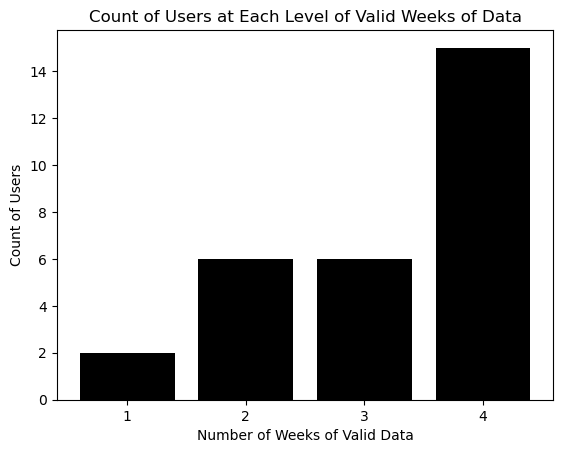

In [7]:
user_valid_data_dict = {}

for x in user_valid_weeks_dict.keys(): # examine dataset of each user
    df_of_weeks_list = []
    week_list = user_valid_weeks_dict[x]
    minutes_filtered = minutes.loc[minutes['Id'].isin([x])].reset_index()
    for week in week_list: # for each 'week' of dates, select the relevant rows in the user's data frame 
        # append the user's list of data frames with a new filtered data frame just containing a certain week's data
        df_of_weeks_list.append(minutes_filtered.loc[minutes_filtered['Date'].isin(week)].reset_index().drop(['level_0', 'index'], axis=1))
    user_valid_data_dict[x] = df_of_weeks_list # assign the list of weekly data frames to the user ID in the dictionary

###
# COPY ALL CODE ABOVE THIS COMMENT TO ENSURE YOU HAVE THE FULL DICTIONARY OF WEEKLY DATA FRAMES FOR EACH USER
###

weeks_count_per_id = []
for x in user_valid_data_dict.keys(): # pretty print number of weekly data frames present for each user
    weeks_count_per_id.append(len(user_valid_data_dict[x]))
    #print("User ID:", x)
    #print("Number of weekly data frames:", len(user_valid_data_dict[x]))
    
# Visualise the amount of weeks of data per user with a barplot
weeks_count_per_id = pd.DataFrame({'Weeks':weeks_count_per_id, 'Count': [1]*len(weeks_count_per_id)})
weeks_count_agg = weeks_count_per_id.groupby('Weeks').sum().reset_index()
plt.bar(weeks_count_agg['Weeks'], weeks_count_agg['Count'], color = 'black')
plt.xticks(weeks_count_agg['Weeks'])
plt.xlabel("Number of Weeks of Valid Data")
plt.ylabel("Count of Users")
plt.title("Count of Users at Each Level of Valid Weeks of Data")

In [8]:
i = 0
for x in user_valid_data_dict.keys(): # look at dates in each weekly data frame for each valid user
    list_df = user_valid_data_dict[x]
    valid_weeks_list = user_valid_weeks_dict[x]
    i += 1
    print(x)
    for y in list_df:
        print(y['Date'].unique())
    print()
    
print(user_valid_data_dict[6117666160][1])

1503960366
['2016-04-13T00:00:00.000000000' '2016-04-14T00:00:00.000000000'
 '2016-04-15T00:00:00.000000000' '2016-04-16T00:00:00.000000000'
 '2016-04-17T00:00:00.000000000' '2016-04-18T00:00:00.000000000'
 '2016-04-19T00:00:00.000000000']
['2016-04-20T00:00:00.000000000' '2016-04-21T00:00:00.000000000'
 '2016-04-22T00:00:00.000000000' '2016-04-23T00:00:00.000000000'
 '2016-04-24T00:00:00.000000000' '2016-04-25T00:00:00.000000000'
 '2016-04-26T00:00:00.000000000']
['2016-04-27T00:00:00.000000000' '2016-04-28T00:00:00.000000000'
 '2016-04-29T00:00:00.000000000' '2016-04-30T00:00:00.000000000'
 '2016-05-01T00:00:00.000000000' '2016-05-02T00:00:00.000000000'
 '2016-05-03T00:00:00.000000000']
['2016-05-04T00:00:00.000000000' '2016-05-05T00:00:00.000000000'
 '2016-05-06T00:00:00.000000000' '2016-05-07T00:00:00.000000000'
 '2016-05-08T00:00:00.000000000' '2016-05-09T00:00:00.000000000'
 '2016-05-10T00:00:00.000000000']

1624580081
['2016-04-13T00:00:00.000000000' '2016-04-14T00:00:00.0000000

In [9]:
intense_mins_dict = {}
intense_weeks_dict = {}
days_per_week = 6

for Id in user_valid_data_dict.keys():
    list_df = user_valid_data_dict[Id]
    valid_weeks_list = user_valid_weeks_dict[Id]
    
    for df in list_df:
        df_copy = df.copy()
        
        # set ActivityHour as the index
        df_copy.set_index("ActivityHour", inplace=True)
        steps = df_copy.iloc[:, 2:-2]

        # check if each minute is more than threshold, and create a boolean dataset for each value
        threshold = 115
        min_above_threshold = steps >= threshold

        # sum of minutes >= threshold grouped by hour
        total = min_above_threshold.sum(axis=1)

        # sum of minutes grouped by day
        daily_result = total.groupby(df_copy.index.date).sum()

        # reset index and rename columns
        result = daily_result.reset_index()
        result.columns = ["Date", "Minutes"]
            
        
        # combine all weeks for each person into a df
        if Id not in intense_mins_dict: 
            intense_mins_dict[Id] = result
            intense_weeks_dict[Id] = 0
        else:
            dfs = [intense_mins_dict[Id], result]
            intense_mins_dict[Id] = pd.concat(dfs, ignore_index=True) 
            
        # +1 to weeks_dict if most days per week >= 15 intense mins    
        count = 0
        for i in result["Minutes"]:
            if i >= 15:
                count += 1
        
        if count >= days_per_week:
            intense_weeks_dict[Id] += 1


In [10]:
for key, value in intense_mins_dict.items():
    print(f"Number of intense minutes for {key}")
    print(value, "\n")

Number of intense minutes for 1503960366
          Date  Minutes
0   2016-04-13       26
1   2016-04-14       35
2   2016-04-15       16
3   2016-04-16       37
4   2016-04-17       32
5   2016-04-18       36
6   2016-04-19       31
7   2016-04-20       14
8   2016-04-21       22
9   2016-04-22       35
10  2016-04-23       19
11  2016-04-24       32
12  2016-04-25       46
13  2016-04-26       23
14  2016-04-27       84
15  2016-04-28       31
16  2016-04-29       21
17  2016-04-30       20
18  2016-05-01        8
19  2016-05-02       43
20  2016-05-03       33
21  2016-05-04       26
22  2016-05-05       11
23  2016-05-06       22
24  2016-05-07       10
25  2016-05-08       36
26  2016-05-09       31
27  2016-05-10       23 

Number of intense minutes for 1624580081
          Date  Minutes
0   2016-04-13        0
1   2016-04-14        1
2   2016-04-15        0
3   2016-04-16        0
4   2016-04-17       18
5   2016-04-18       21
6   2016-04-19        0
7   2016-04-20        1
8   

In [11]:
print("ID         Number of intense weeks")
for key, value in intense_weeks_dict.items():
    print(key, value)

ID         Number of intense weeks
1503960366 3
1624580081 0
1644430081 0
2022484408 0
2026352035 0
2320127002 0
2347167796 0
2873212765 0
3372868164 0
3977333714 0
4020332650 0
4319703577 0
4388161847 0
4445114986 0
4558609924 0
4702921684 0
5553957443 0
5577150313 0
6117666160 0
6290855005 0
6962181067 0
7007744171 0
7086361926 0
8053475328 3
8253242879 0
8378563200 0
8583815059 0
8792009665 0
8877689391 0


# Data Aggregation and Visualization of Intense Activity Minutes and Total Steps

*Author*: AB  
*Start Date*: 2024-10-20 

In this analysis, we aim to visualize the relationship between intense activity minutes and total daily steps for different users. We first ensure that each user's data is aggregated correctly, and then we create an interactive scatter plot to explore the relationship between total steps and intense minutes.

In [15]:
import pandas as pd
import plotly.express as px

# First, we loop through the dictionary `intense_mins_dict`, where each key is a user ID, and the value is the 
# DataFrame containing the user's intense minutes data. We add the `Id` column to each DataFrame so that we can 
# easily distinguish between users in the final dataset.
for user_id, df in intense_mins_dict.items():
    df['Id'] = user_id

# Now, we concatenate all the DataFrames from the intense_mins_dict into a single DataFrame, intense_mins_concat, 
# that contains data for all users.
intense_mins_concat = pd.concat(intense_mins_dict.values(), ignore_index=True)

# Both minutes_agg and intense_mins_concat have a Date column, which we convert to datetime format to facilitate 
# the merging process and ensure proper time-based operations.minutes_agg['Date'] = 
# pd.to_datetime(minutes_agg['Date'])
intense_mins_concat['Date'] = pd.to_datetime(intense_mins_concat['Date'])

# Next, we merge the two DataFrames (minutes_agg and intense_mins_concat) on the Id and Date columns. The 
# resulting DataFrame, all_users_data, contains both the total steps and intense minutes for each user on each 
# date.
all_users_data = pd.merge(minutes_agg, intense_mins_concat, on=['Id', 'Date'], how='inner')

# Finally, we create an interactive scatter plot using Plotly Express. The x-axis represents the total steps per 
# day (DayTotal), and the y-axis represents the intense minutes per day (Minutes). We use different colors to 
# represent different users and include hover data to display the date for each point.
fig = px.scatter(all_users_data, x='DayTotal', y='Minutes', color='Id', 
                 labels={'DayTotal': 'Total Steps per Day', 'Minutes': 'Intense Minutes per Day'},
                 title="Total Steps vs Intense Minutes per Day",
                 hover_data=['Date'])

# Show the interactive plot
fig.show()



The plot will help us visually inspect how intense activity minutes correlate with daily step counts for each user, revealing potential patterns or outliers in their physical activity levels.

End Date: 2024-10-20

# Analysis of Intense Activity Minutes: Filtering, Histogram, and Time Series Plot

*Author*: AB  
*Start Date*: 2024-10-21  

In this analysis, we are interested in exploring how often users meet or exceed 15 minutes of intense activity per day. We will create two visualizations:
1. A histogram to show how many days each user meets the 15-minute threshold.
2. A time series plot showing intense minutes per day for each user.

In [16]:
import plotly.express as px
import pandas as pd


# First, we ensure that the `Date` column is in datetime format to allow for proper time-based filtering and 
# plotting.
intense_mins_concat['Date'] = pd.to_datetime(intense_mins_concat['Date'])

# Next, we create a new column, Meets_15_Minutes, which contains a boolean value indicating whether the user met 
# the 15-minute intense activity threshold on a given day. This will allow us to easily filter and visualize the 
# data.
intense_mins_concat['Meets_15_Minutes'] = intense_mins_concat['Minutes'] >= 15

# Now, we use Plotly Express to create a histogram showing how many days each user exceeded the 15-minute intense 
# activity threshold. The histogram is grouped by user (Id) to allow for easy comparison.
fig_hist = px.histogram(intense_mins_concat, x='Meets_15_Minutes', color='Id',
                        labels={'Meets_15_Minutes': 'Meets 15-Minute Threshold'},
                        title='Number of Days Meeting 15-Minute Intense Activity Threshold',
                        barmode='group')

fig_hist.show()

# This visualization helps us understand how frequently each user meets or exceeds the recommended 15 minutes of 
# intense activity per day.

# Finally, we create a line plot to visualize the time series of intense activity minutes for each user. This 
# plot shows how the user's activity fluctuates over time, providing a clearer picture of their daily intense 
# activity levels.
fig_line = px.line(intense_mins_concat, x='Date', y='Minutes', color='Id',
                   labels={'Minutes': 'Intense Minutes per Day'},
                   title="Time Series of Intense Activity Minutes for Each User",
                   hover_data=['Minutes'])

fig_line.show()

# The line plot allows us to track the daily trends in intense activity for each user, offering insights into 
# periods of high or low activity.



End Date: 2024-10-21